# Stage 2: Deep Learning Foundations and DQN with PyTorch

## 1. PyTorch Tensor Foundations

In [10]:
import numpy as np
import torch

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.12.0
MPS available: True


In [11]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)
print(x_data)

tensor([[1, 2],
        [3, 4]])


In [12]:
data = [[1, 2], [3, 4]]
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_np)

tensor([[1, 2],
        [3, 4]])


In [13]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)
x_ones = torch.ones_like(x_data)
x_rand = torch.rand_like(x_data, dtype = torch.float)
print(f"ones tensor \n {x_ones} \n")
print(f"rand tensor \n {x_rand} \n")

ones tensor 
 tensor([[1, 1],
        [1, 1]]) 

rand tensor 
 tensor([[0.2068, 0.9969],
        [0.3566, 0.8512]]) 



In [14]:
shape = (2, 3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)
print(f"rand tensor : \n {rand_tensor} \n")
print(f"ones tensor : \n {ones_tensor} \n")
print(f"zeros tensor: \n {zeros_tensor} \n")

rand tensor : 
 tensor([[0.2502, 0.4016, 0.2362],
        [0.8184, 0.1599, 0.4454]]) 

ones tensor : 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

zeros tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 



In [15]:
tensor = torch.rand(3,4)
print(f"shape of tensor {tensor.shape}")
print(f"datatype of tensor {tensor.dtype}")
print(f"Device tensor is stored on {tensor.device}")

shape of tensor torch.Size([3, 4])
datatype of tensor torch.float32
Device tensor is stored on cpu


In [16]:
tensor = torch.rand(3,4)

if torch.accelerator.is_available():
    tensor = tensor.to(torch.accelerator.current_accelerator())

print(f"Device tensor is stored on {tensor.device}")

Device tensor is stored on mps:0


In [17]:
tensor = torch.ones(4, 4)
print(f"first row: {tensor[0]}")
print(f"first column: {tensor[:, 0]}")
print(f"last column: {tensor[..., -1]}")
tensor[:, 1] = 0
print(tensor)

first row: tensor([1., 1., 1., 1.])
first column: tensor([1., 1., 1., 1.])
last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [18]:
t1 = torch.cat([tensor, tensor, tensor], dim = 1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


In [19]:
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out = y3)

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])

In [20]:
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(z1)
torch.mul(tensor, tensor, out = z3)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

In [21]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

12.0 <class 'float'>


In [22]:
print(f"{tensor}\n")
tensor.add_(5)
print(tensor)


tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


In [23]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"f: {n}")

t: tensor([1., 1., 1., 1., 1.])
f: [1. 1. 1. 1. 1.]


In [24]:
n = np.ones(5)
print(f"n: {n}")
t = torch.from_numpy(n)
print(f"t: {t}")

n: [1. 1. 1. 1. 1.]
t: tensor([1., 1., 1., 1., 1.], dtype=torch.float64)


In [25]:
np.add(n, 1, out = n)
print(f"n: {n}")
print(f"t: {t}")

n: [2. 2. 2. 2. 2.]
t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


In [26]:
import numpy as np
import torch

cartpole_state = np.array(
    [0.02, -0.01, 0.03, 0.04],
    dtype = np.float32
)

state_tensor = torch.tensor(cartpole_state)

print(f"shape: {state_tensor.shape}")

state_tensor = state_tensor.unsqueeze(0)

print("batch shape", state_tensor.shape)
print("dtype", state_tensor.dtype)

if torch.accelerator.is_available():
    state_tensor = state_tensor.to(
    torch.accelerator.current_accelerator()
    )

print("device", state_tensor.device)
print(state_tensor)


shape: torch.Size([4])
batch shape torch.Size([1, 4])
dtype torch.float32
device mps:0
tensor([[ 0.0200, -0.0100,  0.0300,  0.0400]], device='mps:0')


## 2. Neural Network Foundations: From Linear Models to PyTorch

### 2.1 Manual Forward Pass in PyTorch

In [27]:
import torch

x = torch.tensor([[2.0, 3.0]])
w = torch.tensor([
    [0.5],
    [1.0]
])
b = torch.tensor([[-2.0]])

z = x @ w + b
y_hat = torch.sigmoid(z)

print("x shape:", x.shape)
print("w shape:", w.shape)
print("z:", z)
print("predicted probability:", y_hat)

x shape: torch.Size([1, 2])
w shape: torch.Size([2, 1])
z: tensor([[2.]])
predicted probability: tensor([[0.8808]])


### 2.2 Batch Logistic Regression with Explicit Loops

In [28]:
import torch

# Three training examples, each with two features
X = torch.tensor([
    [1.0, 2.0],
    [2.0, 1.0],
    [-1.0, -2.0],
], dtype = torch.float32)

# Ground-truth labels
Y = torch.tensor([1.0, 1.0, 0.0], dtype = torch.float32)

# Model parameters
w = torch.tensor([0.0, 0.0], dtype = torch.float32)
b = torch.tensor(0.0, dtype = torch.float32)

# Accumulators
cost = torch.tensor(0.0)
dw = torch.zeros_like(w)
db = torch.tensor(0.0)

m = X.shape[0]

for i in range(m):
    x = X[i]
    y = Y[i]

    # Forward propagation
    z = torch.dot(x, w) + b
    a = torch.sigmoid(z)

    loss = -(y * torch.log(a) + (1 - y) * torch.log(1 - a))
    cost += loss

    # Manual backward propagation
    dz = a - y
    dw += x * dz
    db += dz


# Average over all training examples
cost /= m
dw /= m
db /= m

print("cost =", cost.item())
print("dw =", dw)
print("db =", db.item())

learning_rate = 0.1

w = w - learning_rate * dw
b = b - learning_rate * db

print("updated w =", w)
print("updated b =", b.item())   

cost = 0.6931471824645996
dw = tensor([-0.6667, -0.8333])
db = -0.1666666716337204
updated w = tensor([0.0667, 0.0833])
updated b = 0.01666666753590107


### 2.3 Vectorized Logistic Regression with PyTorch

In [29]:
import torch
import torch.nn.functional as F

X = torch.tensor([
    [1.0, 2.0],
    [2.0, 1.0],
    [-1.0, -2.0],
], dtype = torch.float32)

Y = torch.tensor([1.0, 1.0, 0.0], dtype = torch.float32)
w = torch.tensor([0.0, 0.0], dtype = torch.float32)
b = torch.tensor(0.0, dtype = torch.float32)

Z = X @ w + b
A = torch.sigmoid(Z)

cost = F.binary_cross_entropy(A, Y)

m = X.shape[0]
dZ = A - Y
dw = X.T @ dZ / m
db = dZ.mean()

learning_rate = 0.1
w = w - learning_rate * dw
b = b - learning_rate * db

print("Z =", Z)
print("A =", A)
print("cost =", cost.item())
print("dZ =", dZ)
print("dw =", dw)
print("db =", db.item())
print("updated w =", w)
print("updated b =", b.item())


Z = tensor([0., 0., 0.])
A = tensor([0.5000, 0.5000, 0.5000])
cost = 0.6931471824645996
dZ = tensor([-0.5000, -0.5000,  0.5000])
dw = tensor([-0.6667, -0.8333])
db = -0.1666666716337204
updated w = tensor([0.0667, 0.0833])
updated b = 0.01666666753590107


## 3. Building an MLP for CartPole and DQN

### 3.1 CartPole State Tensors and Batch Dimensions

A CartPole state contains four features: cart position, cart velocity, pole angle,
and pole angular velocity.

A single state has shape `[4]`, while a batch of states has shape
`[batch_size, 4]`.

The batch dimension allows the network to process multiple states in one
forward pass. This will later be used when DQN samples multiple transitions
from the replay buffer.

In [30]:
import numpy as np
import torch

state_np = np.array(
    [0.2, -0.15, 0.04 , 0.3],
    dtype = np.float32
)

state_tensor = torch.tensor(
    state_np,
    dtype = torch.float32
                          )

print("NumPy state:", state_np)
print("Tensor state:", state_tensor)

print("Tensor shape:", state_tensor.shape)
print("Tensor dtype:", state_tensor.dtype)
print("Tensor device:", state_tensor.device)


NumPy state: [ 0.2  -0.15  0.04  0.3 ]
Tensor state: tensor([ 0.2000, -0.1500,  0.0400,  0.3000])
Tensor shape: torch.Size([4])
Tensor dtype: torch.float32
Tensor device: cpu


In [31]:
state_batch = state_tensor.unsqueeze(0)

print("Original shape:", state_tensor.shape)
print("Batch shape:", state_batch.shape)
print(state_batch)

Original shape: torch.Size([4])
Batch shape: torch.Size([1, 4])
tensor([[ 0.2000, -0.1500,  0.0400,  0.3000]])


In [32]:
states_batch = torch.tensor(
    [
        [0.02, -0.15, 0.04, 0.30],
        [0.02, -0.15, 0.04, 0.30],
    ],
    dtype = torch.float32
)

print(states_batch)
print("Shape:", states_batch.shape)

tensor([[ 0.0200, -0.1500,  0.0400,  0.3000],
        [ 0.0200, -0.1500,  0.0400,  0.3000]])
Shape: torch.Size([2, 4])


### 3.2 A Linear Layer: From 4 Features to 3 Neurons

A linear layer transforms the four CartPole state features into three neuron
outputs.

Each neuron computes a weighted sum of the inputs and adds a bias:

$$
z = Wx + b
$$

The tensor shape changes from `[batch_size, 4]` to `[batch_size, 3]`.

In [33]:
import torch.nn as nn

linear_layer = nn.Linear(
    in_features = 4,
    out_features = 3
)

print(linear_layer)
print("Weight shape:", linear_layer.weight.shape)
print("Bias shape:", linear_layer.bias.shape)

Linear(in_features=4, out_features=3, bias=True)
Weight shape: torch.Size([3, 4])
Bias shape: torch.Size([3])


In [34]:
z = linear_layer(state_batch)

print("Input shape:", state_batch.shape)
print("Output:", z)
print("Output shape:", z.shape)

Input shape: torch.Size([1, 4])
Output: tensor([[-0.0133, -0.2845, -0.0857]], grad_fn=<AddmmBackward0>)
Output shape: torch.Size([1, 3])


In [35]:
z_manual = (
    state_batch @ linear_layer.weight.T
    + linear_layer.bias    
)

print("PyTorch output:")
print(z)

print("Manual output:")
print(z_manual)

print("Are they equal?")
print(torch.allclose(z, z_manual))

PyTorch output:
tensor([[-0.0133, -0.2845, -0.0857]], grad_fn=<AddmmBackward0>)
Manual output:
tensor([[-0.0133, -0.2845, -0.0857]], grad_fn=<AddBackward0>)
Are they equal?
True


In [36]:
# Inspect the randomly initialized weights of the three neurons
print("Weights:")
print(linear_layer.weight)

# Inspect the randomly initialized bias of each neuron
print("\nBiases:")
print(linear_layer.bias)

Weights:
Parameter containing:
tensor([[ 0.4055,  0.3812, -0.2458,  0.3189],
        [ 0.0351,  0.4073,  0.3836,  0.4380],
        [ 0.4861,  0.3774,  0.4415,  0.2261]], requires_grad=True)

Biases:
Parameter containing:
tensor([-0.1231, -0.3772, -0.2118], requires_grad=True)


### 3.3 ReLU Activation

ReLU replaces negative values with zero and keeps positive values unchanged:

$$
\operatorname{ReLU}(x) = \max(0, x)
$$

It introduces non-linearity, allowing the network to learn more complex
relationships than a stack of linear layers alone.

ReLU is used in hidden layers, but it is not applied to the final DQN output
layer because Q-values are allowed to be negative.

In [37]:
# Create a ReLU activation function
relu = nn.ReLU()

# Apply ReLU to the linear layer output
a = relu(z)

# Compare the values before and after activation
print("Before ReLU:")
print(z)

print("\nAfter ReLU:")
print(a)

print("\nOutput shape:")
print(a.shape)

Before ReLU:
tensor([[-0.0133, -0.2845, -0.0857]], grad_fn=<AddmmBackward0>)

After ReLU:
tensor([[0., 0., 0.]], grad_fn=<ReluBackward0>)

Output shape:
torch.Size([1, 3])


In [38]:
# Reproduce ReLU manually by replacing negative values with zero
a_manual = torch.maximum(
    z,
    torch.tensor(0.0)
)

# Check whether the manual result matches nn.ReLU
print("ReLU output:")
print(a)

print("\nManual output:")
print(a_manual)

print("\nAre the outputs equal?")
print(torch.allclose(a, a_manual))

ReLU output:
tensor([[0., 0., 0.]], grad_fn=<ReluBackward0>)

Manual output:
tensor([[0., 0., 0.]], grad_fn=<MaximumBackward0>)

Are the outputs equal?
True


### 3.4 Output Layer: Predicting Two Q-Values

The output layer produces one Q-value for each possible CartPole action:

- Action `0`: push the cart to the left
- Action `1`: push the cart to the right

For a batch of states, the tensor shape changes from `[batch_size, 3]` to
`[batch_size, 2]`.

Each output row has the form:

$$
[Q(s, 0), Q(s, 1)]
$$

The output layer does not use ReLU or Softmax because Q-values are not
probabilities and may be either positive or negative.

In [39]:
output_layer = nn.Linear(
    in_features = 3,
    out_features = 2
)

# Pass the hidden activations through the output layer
q_values = output_layer(a)

# Inspect the input and output shapes
print("Hidden activation shape:", a.shape)
print("Q-values:", q_values)
print("Q-values shape:", q_values.shape)

Hidden activation shape: torch.Size([1, 3])
Q-values: tensor([[-0.4589,  0.0339]], grad_fn=<AddmmBackward0>)
Q-values shape: torch.Size([1, 2])


In [40]:
# Inspect the trainable parameters of the output layer
print("Output weight shape:", output_layer.weight.shape)
print("Output bias shape:", output_layer.bias.shape)

print("\nOutput weights:")
print(output_layer.weight)

print("\nOutput biases:")
print(output_layer.bias)

Output weight shape: torch.Size([2, 3])
Output bias shape: torch.Size([2])

Output weights:
Parameter containing:
tensor([[-0.5042,  0.4876, -0.2974],
        [-0.4162, -0.0413,  0.1019]], requires_grad=True)

Output biases:
Parameter containing:
tensor([-0.4589,  0.0339], requires_grad=True)


### 3.5 Selecting a Greedy Action from Q-Values

A greedy policy selects the action with the largest predicted Q-value.

For one state, the network may produce:

$$
[Q(s, 0), Q(s, 1)]
$$

`torch.argmax()` returns the index of the largest Q-value, and that index is
used as the selected action.

For example:

```text
Q-values: [0.4, 1.2]
Greedy action: 1

In [41]:
# Select the action with the highest predicted Q-value
greedy_action_tensor = torch.argmax(
    q_values,
    dim = 1
)

greedy_action = greedy_action_tensor.item()

# Inspect the predicted Q-values and selected action
print("Q-values:", q_values)
print("Action tensor:", greedy_action_tensor)
print("Selected greedy action:", greedy_action)

Q-values: tensor([[-0.4589,  0.0339]], grad_fn=<AddmmBackward0>)
Action tensor: tensor([1])
Selected greedy action: 1


### 3.6 Batch Forward Pass and Greedy Action Selection

A batch forward pass allows the network to process multiple CartPole states at
the same time.

For a batch of states:

```text
States:          [batch_size, 4]
Q-values:        [batch_size, 2]
Greedy actions:  [batch_size]

In [42]:
z_batch = linear_layer(states_batch)
a_batch = relu(z_batch)
q_values_batch = output_layer(a_batch)

# Inspect how the batch dimension is preserved through the network
print("Input shape:", states_batch.shape)
print("Hidden linear output shape:", z_batch.shape)
print("Hidden activation shape:", a_batch.shape)
print("Q-values shape:", q_values_batch.shape)

print("\nQ-values for both states:")
print(q_values_batch)

Input shape: torch.Size([2, 4])
Hidden linear output shape: torch.Size([2, 3])
Hidden activation shape: torch.Size([2, 3])
Q-values shape: torch.Size([2, 2])

Q-values for both states:
tensor([[-0.4589,  0.0339],
        [-0.4589,  0.0339]], grad_fn=<AddmmBackward0>)


In [43]:
greedy_actions = torch.argmax(
    q_values_batch,
    dim = 1
)

# Inspect the Q-values and selected action for each state
print("Q-values batch:")
print(q_values_batch)

print("\nGreedy actions:")
print(greedy_actions)

print("\nGreedy actions shape:")
print(greedy_actions.shape)

Q-values batch:
tensor([[-0.4589,  0.0339],
        [-0.4589,  0.0339]], grad_fn=<AddmmBackward0>)

Greedy actions:
tensor([1, 1])

Greedy actions shape:
torch.Size([2])


### 3.7 Building the Complete Network with `nn.Module`

A PyTorch neural network is usually defined by creating a class that inherits
from `nn.Module`.

The `__init__()` method defines the layers of the network, while the
`forward()` method defines how input data passes through those layers.

For this network, the data flow is:

`4 state features → hidden linear layer → ReLU → output linear layer → 2 Q-values`

Calling `q_network(states)` automatically runs the `forward()` method.

Because the layers are stored as attributes of the module, PyTorch
automatically tracks their weights and biases as trainable parameters.

In [44]:
import torch.nn as nn

class CartPoleQNetwork(nn.Module):

    def __init__(self):
        # Initialize the parent nn.Module class
        super().__init__()

         # Create a hidden layer:
        # 4 CartPole state features -> 3 hidden neuron outputs
        self.hidden_layer = nn.Linear(
            in_features=4,
            out_features=3
        )

        # Create the ReLU activation function
        self.relu = nn.ReLU()

        # Create the output layer:
        # 3 hidden activations -> 2 action Q-values
        self.output_layer = nn.Linear(
            in_features=3,
            out_features=2
        )

    def forward(self, x):
        # Pass the input states through the hidden linear layer
        z = self.hidden_layer(x)

        # Apply ReLU to introduce nonlinearity
        a = self.relu(z)

        # Produce one predicted Q-value for each action
        q_values = self.output_layer(a)

        # Return the final Q-value predictions
        return q_values



In [45]:
q_network = CartPoleQNetwork()
print(q_network)

CartPoleQNetwork(
  (hidden_layer): Linear(in_features=4, out_features=3, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=3, out_features=2, bias=True)
)


In [46]:
# Display the name and shape of every trainable parameter
for parameter_name, parameter in q_network.named_parameters():
    print(parameter_name, parameter.shape)

hidden_layer.weight torch.Size([3, 4])
hidden_layer.bias torch.Size([3])
output_layer.weight torch.Size([2, 3])
output_layer.bias torch.Size([2])


In [49]:
q_values = q_network(state_batch)

# Inspect the network input and output
print("Input state:")
print(state_batch)

print("\nInput shape:")
print(state_batch.shape)

print("\nPredicted Q-values:")
print(q_values)

print("\nQ-values shape:")
print(q_values.shape)

Input state:
tensor([[ 0.2000, -0.1500,  0.0400,  0.3000]])

Input shape:
torch.Size([1, 4])

Predicted Q-values:
tensor([[ 0.1433, -0.2768]], grad_fn=<AddmmBackward0>)

Q-values shape:
torch.Size([1, 2])


In [51]:
z_manual = q_network.hidden_layer(state_batch)
a_manual = q_network.relu(z_manual)
q_values_manual = q_network.output_layer(a_manual)

# Compare the automatic and manual forward passes
print("Network output:")
print(q_values)

print("\nManual output:")
print(q_values_manual)

print("\nAre the outputs equal?")
print(torch.allclose(q_values, q_values_manual))

Network output:
tensor([[ 0.1433, -0.2768]], grad_fn=<AddmmBackward0>)

Manual output:
tensor([[ 0.1433, -0.2768]], grad_fn=<AddmmBackward0>)

Are the outputs equal?
True


### 3.8 Measuring Prediction Error with MSE Loss

The network produces predicted Q-values, while the target tensor represents
the values that the network should learn to predict.

Mean Squared Error measures the average squared difference between the
predictions and targets:

$$
\mathrm{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
\hat{y}_i-y_i
\right)^2
$$

A smaller loss means that the predicted Q-values are closer to the target
Q-values.

The final loss is a scalar tensor that will be used for backpropagation.

In [54]:
target_q_values = torch.tensor([
    [1.0, -0.5]
], dtype = torch.float32)

loss_function = nn.MSELoss()

loss = loss_function(
    q_values,
    target_q_values
)

# Inspect the predictions, targets, and resulting loss
print("Predicted Q-values:")
print(q_values)

print("\nTarget Q-values:")
print(target_q_values)

print("\nMSE loss:")
print(loss)

# MSELoss uses mean reduction by default, 
# so the loss is a scalar tensor with an empty shape.
print("\nLoss shape:")
print(loss.shape)


Predicted Q-values:
tensor([[ 0.1433, -0.2768]], grad_fn=<AddmmBackward0>)

Target Q-values:
tensor([[ 1.0000, -0.5000]])

MSE loss:
tensor(0.3919, grad_fn=<MseLossBackward0>)

Loss shape:
torch.Size([])


### 3.9 Backpropagation and Gradient Inspection

Calling `loss.backward()` applies backpropagation through the computation graph.

PyTorch calculates how much each trainable parameter contributed to the loss
and stores the resulting gradients in each parameter's `.grad` attribute.

The process is:

`loss → backward through the network → compute parameter gradients`

Backpropagation only computes gradients. It does not update the network
parameters by itself.

Gradients accumulate by default, so they must normally be cleared before the
next backward pass.

In [56]:
# Clear any gradients left from previous computations
q_network.zero_grad()

# Run a fresh forward pass to build a new computation graph
q_values_for_grad = q_network(state_batch)

# Compute the loss from the fresh predictions
loss_for_grad = loss_function(
    q_values_for_grad,
    target_q_values
)

# Compute gradients for all trainable network parameters
loss_for_grad.backward()

# Display the gradient of every trainable parameter
for parameter_name, parameter in q_network.named_parameters():
    print(f"{parameter_name} gradient:")
    print(parameter.grad)
    print("Gradient shape:", parameter.grad.shape)
    print()


hidden_layer.weight gradient:
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0728, -0.0546,  0.0146,  0.1092]])
Gradient shape: torch.Size([3, 4])

hidden_layer.bias gradient:
tensor([0.0000, 0.0000, 0.3642])
Gradient shape: torch.Size([3])

output_layer.weight gradient:
tensor([[ 0.0000,  0.0000, -0.0085],
        [ 0.0000,  0.0000,  0.0022]])
Gradient shape: torch.Size([2, 3])

output_layer.bias gradient:
tensor([-0.8567,  0.2232])
Gradient shape: torch.Size([2])



### 3.10 Updating Network Parameters with an Optimizer

A complete parameter update contains three main steps:

1. `optimizer.zero_grad()` clears gradients left from the previous update.
2. `loss.backward()` computes new gradients using backpropagation.
3. `optimizer.step()` updates the network parameters using those gradients.

The training process is:

`clear old gradients → forward pass → compute loss → backward pass → update parameters`

After `optimizer.step()`, the network should produce slightly different
predictions, ideally resulting in a lower loss.

This same optimization pattern will later be used to train the online network
in DQN.

#### Single Optimization Step: Parameter Update Flow

This cell demonstrates how one complete optimization step updates the network parameters.

Create the optimizer  
↓  
Save a snapshot of the output bias before the update  
↓  
Clear previously accumulated gradients  
↓  
Run a forward pass through the network  
↓  
Compute the prediction loss  
↓  
Backpropagate the loss and store parameter gradients in `.grad`  
↓  
Update the network parameters with `optimizer.step()`  
↓  
Save a snapshot of the output bias after the update  
↓  
Compare the parameter values before and after the update

In [70]:
# Create an SGD optimizer to update all trainable network parameters
optimizer = torch.optim.SGD(
    q_network.parameters(),
    lr = 0.1
)

# Save a copy of the output bias before the update
bias_before = (
    q_network.output_layer.bias
             .detach()
             .clone()             
)

# Clear gradients left from the previous backward pass
optimizer.zero_grad()

# Run a fresh forward pass
q_values_before_update = q_network(state_batch)

# Compute the loss before updating the parameters
loss_before_update = loss_function(
    q_values_before_update,
    target_q_values
)

# Compute gradients for the current parameters
loss_before_update.backward()

# Update all trainable parameters using their gradients
optimizer.step()

# Save the output bias after the update
bias_after = (
    q_network.output_layer.bias
              .detach()
              .clone()    
)

print("Output bias before update:")
print(bias_before)

print("\nOutput bias gradient:")
print(q_network.output_layer.bias.grad)

print("\nOutput bias after update:")
print(bias_after)

print("\nDid the bias change?")
print(not torch.allclose(bias_before, bias_after))

Output bias before update:
tensor([ 0.4973, -0.3665])

Output bias gradient:
tensor([-0.5027,  0.1335])

Output bias after update:
tensor([ 0.5476, -0.3799])

Did the bias change?
True


### 3.11 Verifying the Loss After the Parameter Update

After `optimizer.step()`, the model parameters have changed, but the existing
loss tensor still contains the value computed before the update.

To evaluate the updated model, we need to run another forward pass and compute
the loss again using the new parameter values.

In [71]:
q_values_after_update = q_network(state_batch)

loss_after_update = loss_function(
    q_values_after_update,
    target_q_values
)

# Compare the loss values before and after the update
print(f"Loss before update: {loss_before_update.item():.6f}")
print(f"Loss after update:  {loss_after_update.item():.6f}")

Loss before update: 0.135262
Loss after update:  0.109562


### 3.12 Building a Complete Training Loop

A neural network normally requires many parameter updates rather than a single
update.

During each training iteration, we clear the old gradients, run a forward pass,
compute the loss, perform backpropagation, and update the model parameters.

In [73]:
# Set the number of times the network will train on the current batch
num_epochs = 20

# Store the loss from each training epoch
loss_history = []

for epoch in range(num_epochs):
    # Clear gradients left from the previous backward pass
    optimizer.zero_grad()

    # Run a forward pass using the current network parameters
    predicted_q_values = q_network(state_batch)

     # Measure the difference between predictions and target Q-values
    loss = loss_function(
        predicted_q_values,
        target_q_values
    )

    # Compute gradients for all trainable parameters
    loss.backward()

     # Update the network parameters
    optimizer.step()

    # Save the numerical loss value for later inspection
    loss_history.append(loss.item())

    # Print progress at selected epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:2d}/{num_epochs}, "
            f"Loss: {loss.item():.6f}"
        )
    

Epoch  1/20, Loss: 0.109562
Epoch  5/20, Loss: 0.047163
Epoch 10/20, Loss: 0.016445
Epoch 15/20, Loss: 0.005734
Epoch 20/20, Loss: 0.001999


### 3.13 Mini-Batch Training

Instead of training on the entire dataset at once, we can divide the data into
smaller mini-batches.

For each mini-batch, the network performs a forward pass, computes the loss,
runs backpropagation, and updates its parameters.

Mini-batch training is the standard approach used in deep learning and DQN.

In [75]:
from torch.utils.data import TensorDataset, DataLoader

# Make the synthetic dataset reproducible
torch.manual_seed(42)

# Create 50 synthetic CartPole-like states
large_state_batch = torch.randn(50,4)

# Create learnable target Q-values for action 0
target_q_action_0 = torch.relu(
    0.8 * large_state_batch[:, 0]
    - 0.4 * large_state_batch[:, 1]
    + 0.6 * large_state_batch[:, 2]
    + 0.2 * large_state_batch[:, 3]
)

# Create learnable target Q-values for action 1
target_q_action_1 = torch.relu(
    -0.5 * large_state_batch[:, 0]
    + 0.7 * large_state_batch[:, 1]
    - 0.2 * large_state_batch[:, 2]
    + 0.9 * large_state_batch[:, 3]
)

# Combine the two action targets into shape [50, 2]
large_target_q_values = torch.stack(
    (
        target_q_action_0,
        target_q_action_1
    ),
    dim=1
)

print("State data shape:", large_state_batch.shape)
print("Target data shape:", large_target_q_values.shape)


State data shape: torch.Size([50, 4])
Target data shape: torch.Size([50, 2])


In [76]:
# Pair each state with its corresponding target Q-values
large_training_dataset = TensorDataset(
    large_state_batch,
    large_target_q_values
)

# Divide 50 samples into mini-batches of 10 samples
large_training_loader = DataLoader(
    large_training_dataset,
    batch_size=10,
    shuffle=True
)

print("Number of samples:", len(large_training_dataset))
print("Number of mini-batches:", len(large_training_loader))


Number of samples: 50
Number of mini-batches: 5


In [77]:
# Inspect every mini-batch produced by the DataLoader
for batch_index, (mini_batch_states, mini_batch_targets) in enumerate(
    large_training_loader
):
    print(f"Mini-batch {batch_index + 1}")
    print("State batch shape:", mini_batch_states.shape)
    print("Target batch shape:", mini_batch_targets.shape)
    print()

Mini-batch 1
State batch shape: torch.Size([10, 4])
Target batch shape: torch.Size([10, 2])

Mini-batch 2
State batch shape: torch.Size([10, 4])
Target batch shape: torch.Size([10, 2])

Mini-batch 3
State batch shape: torch.Size([10, 4])
Target batch shape: torch.Size([10, 2])

Mini-batch 4
State batch shape: torch.Size([10, 4])
Target batch shape: torch.Size([10, 2])

Mini-batch 5
State batch shape: torch.Size([10, 4])
Target batch shape: torch.Size([10, 2])



#### How mini-batch loss and epoch loss are computed

For one mini-batch of 10 states:

**10 states → 20 predicted Q-values → 20 squared errors → mean of the 20 errors → one mini-batch loss**

After each mini-batch, `epoch_loss += loss.item()` adds the current mini-batch loss to the total loss for that epoch.

After all 5 mini-batches are processed, `average_epoch_loss = epoch_loss / len(large_training_loader)` divides their total loss by 5 to obtain the average loss for the whole epoch.

In [78]:
# Create a new optimizer for this mini-batch exercise
optimizer = torch.optim.SGD(
    q_network.parameters(),
    lr = 0.1
)

# Set the number of complete passes over the dataset
num_epochs = 50

mini_batch_loss_history = []

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for mini_batch_states, mini_batch_targets in large_training_loader:

        optimizer.zero_grad()

        predicted_q_values = q_network(mini_batch_states)

        loss = loss_function(
            predicted_q_values,
            mini_batch_targets
        )

        loss.backward()

        optimizer.step()

        # Add the current mini-batch loss to the epoch total
        epoch_loss += loss.item()

    # Compute the average loss across the five mini-batches
    average_epoch_loss = (
        epoch_loss / len(large_training_loader)
    )

    # Save the average loss for this epoch
    mini_batch_loss_history.append(average_epoch_loss)
    
    # Print selected epochs
    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:2d}/{num_epochs}, "
            f"Average loss: {average_epoch_loss:.6f}"
        )


Epoch  1/50, Average loss: 1.161631
Epoch 10/50, Average loss: 0.191736
Epoch 20/50, Average loss: 0.064550
Epoch 30/50, Average loss: 0.055714
Epoch 40/50, Average loss: 0.053744
Epoch 50/50, Average loss: 0.051629


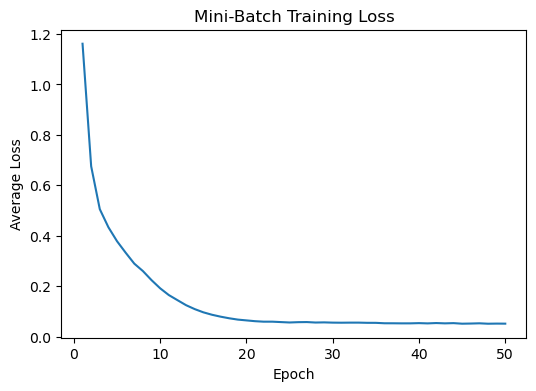

In [80]:
import matplotlib.pyplot as plt

# Create epoch numbers starting from 1
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))

# Plot the average loss recorded after each epoch
plt.plot(
    epochs,
    mini_batch_loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Mini-Batch Training Loss")
plt.show()

### 3.14 Using `torch.no_grad()` for Q-Value Inference

During training, PyTorch builds a computation graph so that gradients can be
computed during backpropagation.

When we only need Q-value predictions, `torch.no_grad()` disables gradient
tracking and avoids building an unnecessary computation graph.

In DQN, this is useful for action selection, evaluation, and computing target
Q-values.

In [81]:
# Select five states for Q-value inference
evaluation_states = large_state_batch[:5]

# Run a normal forward pass with gradient tracking
q_values_with_grad = q_network(evaluation_states)

# Run the same forward pass without gradient tracking
with torch.no_grad():
    q_values_without_grad = q_network(evaluation_states)

# Check whether the outputs track gradients
print(
    "With gradient tracking:",
    q_values_with_grad.requires_grad
)

print(
    "Without gradient tracking:",
    q_values_without_grad.requires_grad
)

# Verify that both forward passes produce the same Q-values
print(
    "Predictions are equal:",
    torch.allclose(
        q_values_with_grad,
        q_values_without_grad
    )
)

With gradient tracking: True
Without gradient tracking: False
Predictions are equal: True


## 4. DQN Bridge: From Network Outputs to TD Learning

### 4.1 Selecting \(Q(s,a)\) with `gather()`

A DQN outputs one Q-value for every possible action.

During training, each transition contains the action that was actually taken.
Therefore, we must select the Q-value corresponding to that action from each
row of the network output.

In [84]:
# Select five states for the DQN bridge exercise
bridge_states = large_state_batch[:5]

all_action_q_values = q_network(bridge_states)

# Specify the action taken for each state
bridge_actions = torch.tensor(
    [0, 1, 0, 1, 1],
    dtype=torch.long
).unsqueeze(1)

selected_action_q_values = all_action_q_values.gather(
    dim = 1,
    index = bridge_actions
)

# Inspect the tensors and their shapes
print("All action Q-values:")
print(all_action_q_values)
print("Shape:", all_action_q_values.shape)

print("\nActions:")
print(bridge_actions)
print("Shape:", bridge_actions.shape)

print("\nSelected action Q-values:")
print(selected_action_q_values)
print("Shape:", selected_action_q_values.shape)


All action Q-values:
tensor([[ 0.7419, -0.1298],
        [ 0.7419, -0.1298],
        [-0.0929,  0.3608],
        [-0.0589,  0.8175],
        [ 0.5889,  0.0091]], grad_fn=<AddmmBackward0>)
Shape: torch.Size([5, 2])

Actions:
tensor([[0],
        [1],
        [0],
        [1],
        [1]])
Shape: torch.Size([5, 1])

Selected action Q-values:
tensor([[ 0.7419],
        [-0.1298],
        [-0.0929],
        [ 0.8175],
        [ 0.0091]], grad_fn=<GatherBackward0>)
Shape: torch.Size([5, 1])


### 4.2 Computing the TD Target

Each transition contains a reward, a next state, and a terminal flag.

For a non-terminal transition, the TD target is the immediate reward plus the
discounted maximum Q-value of the next state.

For a terminal transition, there is no future return, so the TD target is only
the immediate reward.

$$
y = r + \gamma (1 - \mathrm{done}) \max_{a'} Q(s', a')
$$

In [88]:
# Create the remaining parts of five example transitions
bridge_rewards = torch.tensor(
    [1.0, 1.0, 1.0, 1.0, 1.0],
    dtype = torch.float32
).unsqueeze(1)

bridge_next_stages = large_state_batch[5:10]

bridge_dones = torch.tensor(
    [0.0, 0.0, 1.0, 0.0, 1.0],
    dtype = torch.float
).unsqueeze(1)

gamma = 0.99

# Compute next-state Q-values without gradient tracking
with torch.no_grad():
    next_all_action_q_values = q_network(bridge_next_stages)

    max_next_q_values = next_all_action_q_values.max(
        dim = 1,
        keepdim = True
    ).values

    bridge_target_q_values = (
        bridge_rewards
        + gamma
        * max_next_q_values
        * (1.0 - bridge_dones)
    )
    
# Inspect the TD target calculation
print("Next-state Q-values:")
print(next_all_action_q_values)
print("Shape:", next_all_action_q_values.shape)

print("\nMaximum next-state Q-values:")
print(max_next_q_values)
print("Shape:", max_next_q_values.shape)

print("\nDone flags:")
print(bridge_dones)

print("\nTD target Q-values:")
print(bridge_target_q_values)
print("Shape:", bridge_target_q_values.shape)


Next-state Q-values:
tensor([[ 0.3072,  2.4301],
        [ 0.6363,  1.2405],
        [ 0.1481,  0.9399],
        [-0.0212,  1.6664],
        [ 0.7118, -0.1230]])
Shape: torch.Size([5, 2])

Maximum next-state Q-values:
tensor([[2.4301],
        [1.2405],
        [0.9399],
        [1.6664],
        [0.7118]])
Shape: torch.Size([5, 1])

Done flags:
tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]])

TD target Q-values:
tensor([[3.4058],
        [2.2281],
        [1.0000],
        [2.6497],
        [1.0000]])
Shape: torch.Size([5, 1])
